In [39]:
import pandas as pd

df = pd.read_csv('study_logs_20260428_155207.csv')
df.head()

,id,user_id,group_name,event_type,event_time,payload
0,44,1,G1,page_duration,2026-03-16T21:33:26.659126+00:00,"{""page"": ""ethics"", ""event"": ""page_duration"", ""..."
1,45,1,G1,page_duration,2026-03-16T21:35:32.363304+00:00,"{""page"": ""unknown"", ""event"": ""page_duration"", ..."
2,46,1,G1,page_duration,2026-03-17T00:42:23.877946+00:00,"{""page"": ""unknown"", ""event"": ""page_duration"", ..."
3,47,1,G1,page_duration,2026-03-17T00:42:23.915613+00:00,"{""page"": ""ethics"", ""event"": ""page_duration"", ""..."
4,48,1,G1,page_duration,2026-03-17T00:43:29.569630+00:00,"{""page"": ""pre_assessment"", ""event"": ""page_dura..."


In [40]:
questionnaire = df[df['event_type'] == 'questionnaire_completed']

grouped = {name: group.reset_index(drop=True) for name, group in questionnaire.groupby('group_name')}

study_log_g1 = grouped.get('G1')
study_log_g2 = grouped.get('G2')

study_log_g1.to_csv('study_log_g1.csv', index=False)
study_log_g2.to_csv('study_log_g2.csv', index=False)

print(f"G1: {len(study_log_g1)} responses → study_log_g1.csv")
print(f"G2: {len(study_log_g2)} responses → study_log_g2.csv")

G1: 35 responses → study_log_g1.csv
G2: 37 responses → study_log_g2.csv


In [41]:
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Parse payload into responses + demographics for each group
def parse_group(csv_path):
    df = pd.read_csv(csv_path)
    records = []
    for _, row in df.iterrows():
        p = json.loads(row['payload'])
        record = {'user_id': row['user_id']}
        record.update(p.get('responses', {}))
        record.update(p.get('demographics', {}))
        records.append(record)
    return pd.DataFrame(records)

g1 = parse_group('study_log_g1.csv')
g2 = parse_group('study_log_g2.csv')

print(f"G1: {len(g1)} participants | G2: {len(g2)} participants")

G1: 35 participants | G2: 37 participants


In [42]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

# ── Shared style ──────────────────────────────────────────────────────────────
C1, C2 = '#4C72B0', '#DD8452'          # G1 control blue, G2 treatment orange
ALPHA   = 0.18                          # fill alpha for distributions
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})

# ── Helper: Mann-Whitney U + Cohen's d ───────────────────────────────────────
def mwu_cohend(a, b):
    a, b = a.dropna(), b.dropna()
    _, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    pooled = np.sqrt(((len(a)-1)*a.std()**2 + (len(b)-1)*b.std()**2) / (len(a)+len(b)-2))
    d = (a.mean() - b.mean()) / pooled if pooled else 0
    return p, d

def sig_stars(p):
    if p < .001: return '***'
    if p < .01:  return '**'
    if p < .05:  return '*'
    return 'ns'

print("Helpers loaded.")

Helpers loaded.


## 1 · Demographics
*Are the two groups comparable?*

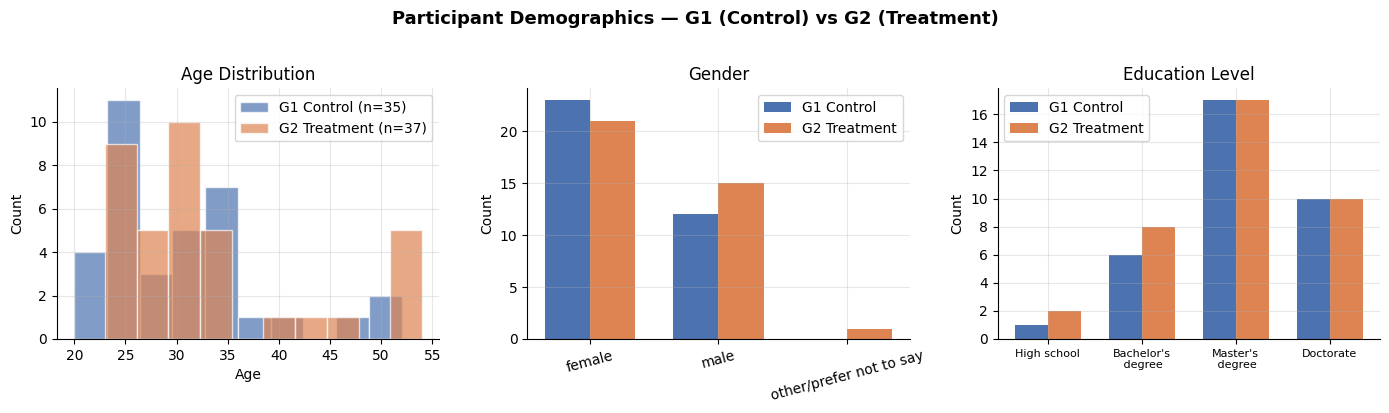

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Participant Demographics — G1 (Control) vs G2 (Treatment)', fontsize=13, fontweight='bold', y=1.02)

# Age distribution
ax = axes[0]
ax.hist(g1['age'], bins=10, color=C1, alpha=0.7, label=f'G1 Control (n={len(g1)})', edgecolor='white')
ax.hist(g2['age'], bins=10, color=C2, alpha=0.7, label=f'G2 Treatment (n={len(g2)})', edgecolor='white')
ax.set_title('Age Distribution')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()

# Gender
ax = axes[1]
cats = sorted(set(g1['gender'].unique()) | set(g2['gender'].unique()))
x = np.arange(len(cats))
w = 0.35
ax.bar(x - w/2, [g1['gender'].value_counts().get(c, 0) for c in cats], w, color=C1, label='G1 Control')
ax.bar(x + w/2, [g2['gender'].value_counts().get(c, 0) for c in cats], w, color=C2, label='G2 Treatment')
ax.set_xticks(x); ax.set_xticklabels(cats, rotation=15)
ax.set_title('Gender')
ax.set_ylabel('Count')
ax.legend()

# Education
ax = axes[2]
edu_order = ["High school", "Bachelor's degree", "Master's degree", "Doctorate"]
x = np.arange(len(edu_order))
ax.bar(x - w/2, [g1['education'].value_counts().get(c, 0) for c in edu_order], w, color=C1, label='G1 Control')
ax.bar(x + w/2, [g2['education'].value_counts().get(c, 0) for c in edu_order], w, color=C2, label='G2 Treatment')
ax.set_xticks(x); ax.set_xticklabels([e.replace("'s", "'s\n") for e in edu_order], fontsize=8)
ax.set_title('Education Level')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.savefig('fig1_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

## 2 · Primary Outcomes — Violin + Box plots
*The three constructs the study was designed to measure: trust, recommendation usefulness, and behavioural intent.*

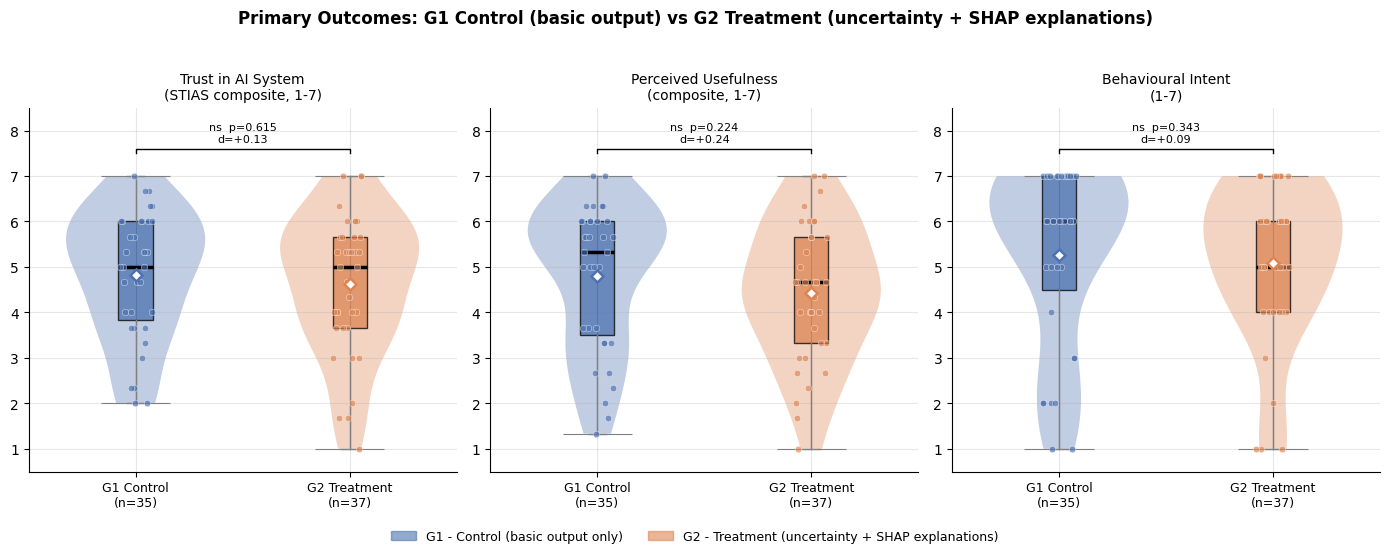

In [44]:
# Composite scores
g1['trust_score']  = g1[['q_stias_trust','q_stias_reliable','q_stias_understandable']].mean(axis=1)
g2['trust_score']  = g2[['q_stias_trust','q_stias_reliable','q_stias_understandable']].mean(axis=1)
g1['useful_score'] = g1[['q_ai_reasonable','q_ai_trust_recs','q_ai_recs_useful']].mean(axis=1)
g2['useful_score'] = g2[['q_ai_reasonable','q_ai_trust_recs','q_ai_recs_useful']].mean(axis=1)

outcomes = [
    ('trust_score',              'Trust in AI System\n(STIAS composite, 1-7)'),
    ('useful_score',             'Perceived Usefulness\n(composite, 1-7)'),
    ('q_intent_stress_technique','Behavioural Intent\n(1-7)'),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle(
    'Primary Outcomes: G1 Control (basic output) vs G2 Treatment (uncertainty + SHAP explanations)',
    fontsize=12, fontweight='bold', y=1.03
)

rng = np.random.default_rng(42)
for ax, (col, label) in zip(axes, outcomes):
    a, b = g1[col].dropna(), g2[col].dropna()
    p, d = mwu_cohend(a, b)

    parts = ax.violinplot([a, b], positions=[1, 2], showmedians=False, widths=0.65)
    for pc, color in zip(parts['bodies'], [C1, C2]):
        pc.set_facecolor(color); pc.set_alpha(0.35)
    for key in ['cbars', 'cmins', 'cmaxes']:
        parts[key].set_color('gray'); parts[key].set_linewidth(0.8)

    bp = ax.boxplot([a, b], positions=[1, 2], widths=0.16, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2.5),
                    whiskerprops=dict(color='gray', linewidth=1),
                    capprops=dict(color='gray', linewidth=1),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4))
    bp['boxes'][0].set_facecolor(C1); bp['boxes'][0].set_alpha(0.75)
    bp['boxes'][1].set_facecolor(C2); bp['boxes'][1].set_alpha(0.75)

    for vals, pos, color in [(a, 1, C1), (b, 2, C2)]:
        jitter = rng.uniform(-0.08, 0.08, len(vals))
        ax.scatter(pos + jitter, vals, color=color, s=22, alpha=0.65, zorder=4,
                   edgecolors='white', linewidths=0.4)

    ax.plot(1, a.mean(), marker='D', color='white', markersize=6, zorder=5,
            markeredgecolor=C1, markeredgewidth=1.8)
    ax.plot(2, b.mean(), marker='D', color='white', markersize=6, zorder=5,
            markeredgecolor=C2, markeredgewidth=1.8)

    y_top = max(a.max(), b.max()) + 0.5
    ax.plot([1, 1, 2, 2], [y_top, y_top+0.1, y_top+0.1, y_top], color='black', lw=1)
    stars = sig_stars(p)
    ax.text(1.5, y_top + 0.25, f'{stars}  p={p:.3f}\nd={d:+.2f}', ha='center', fontsize=8)

    ax.set_xticks([1, 2])
    ax.set_xticklabels([f'G1 Control\n(n={len(a)})', f'G2 Treatment\n(n={len(b)})'], fontsize=9)
    ax.set_title(label, fontsize=10)
    ax.set_ylim(0.5, y_top + 1.0)

p1 = mpatches.Patch(color=C1, alpha=0.6, label='G1 - Control (basic output only)')
p2 = mpatches.Patch(color=C2, alpha=0.6, label='G2 - Treatment (uncertainty + SHAP explanations)')
fig.legend(handles=[p1, p2], loc='lower center', ncol=2, fontsize=9,
           bbox_to_anchor=(0.5, -0.06), frameon=False)
plt.tight_layout()
plt.savefig('fig2_primary_outcomes.png', dpi=150, bbox_inches='tight')
plt.show()


## 3 · Effect Size Summary — All Scale Items
*How large is the G1 vs G2 difference on every measured item?*

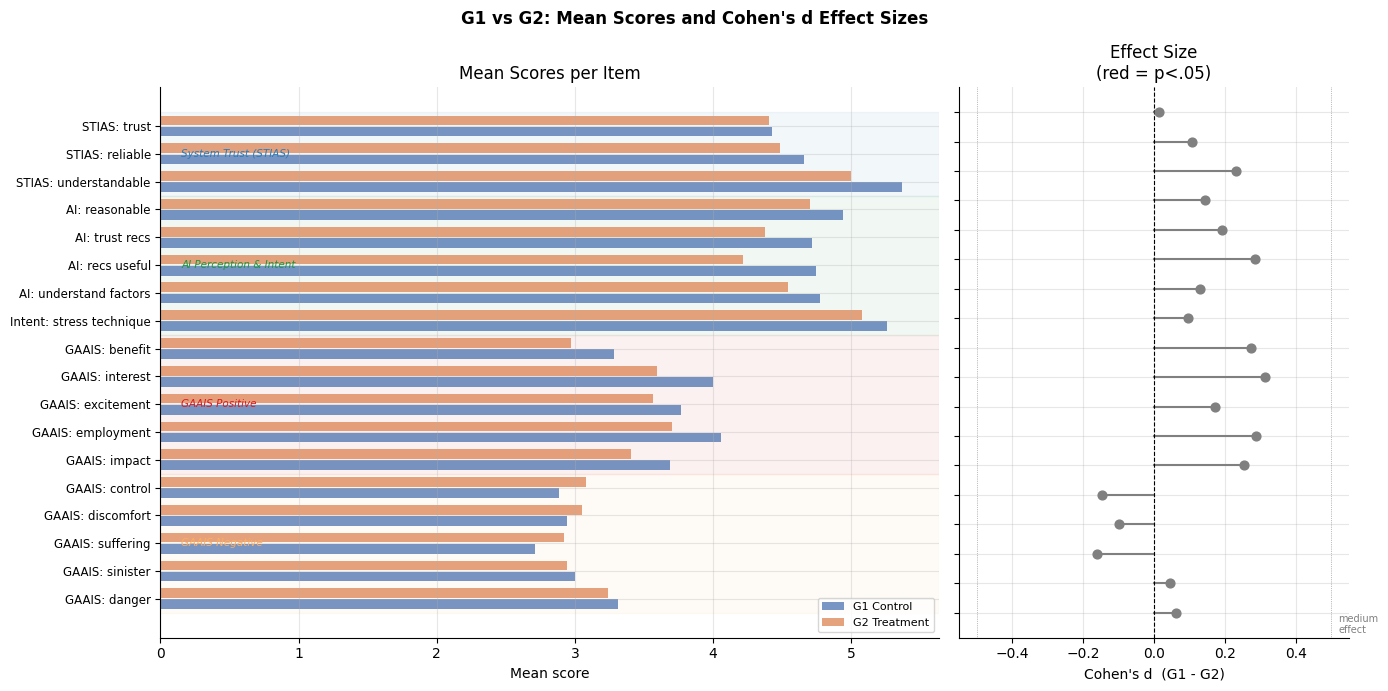

In [45]:
all_cols = [
    'q_stias_trust','q_stias_reliable','q_stias_understandable',
    'q_ai_reasonable','q_ai_trust_recs','q_ai_recs_useful','q_ai_understand_factors',
    'q_intent_stress_technique',
    'q_gaais_benefit','q_gaais_interest','q_gaais_excitement','q_gaais_employment','q_gaais_impact',
    'q_gaais_control','q_gaais_discomfort','q_gaais_suffering','q_gaais_sinister','q_gaais_danger',
]
labels = [
    'STIAS: trust','STIAS: reliable','STIAS: understandable',
    'AI: reasonable','AI: trust recs','AI: recs useful','AI: understand factors',
    'Intent: stress technique',
    'GAAIS: benefit','GAAIS: interest','GAAIS: excitement','GAAIS: employment','GAAIS: impact',
    'GAAIS: control','GAAIS: discomfort','GAAIS: suffering','GAAIS: sinister','GAAIS: danger',
]
sections = [
    (0,  3,  '#2c7bb6', 'System Trust (STIAS)'),
    (3,  8,  '#1a9641', 'AI Perception & Intent'),
    (8,  13, '#d7191c', 'GAAIS Positive'),
    (13, 18, '#fdae61', 'GAAIS Negative'),
]

ds, ps, means1, means2 = [], [], [], []
for col in all_cols:
    a, b = g1[col].dropna(), g2[col].dropna()
    p, d = mwu_cohend(a, b)
    ds.append(d); ps.append(p)
    means1.append(a.mean()); means2.append(b.mean())

y = np.arange(len(all_cols))
fig, axes = plt.subplots(1, 2, figsize=(14, 7), gridspec_kw={'width_ratios': [2, 1]})
fig.suptitle("G1 vs G2: Mean Scores and Cohen's d Effect Sizes",
             fontsize=12, fontweight='bold')

# Left: mean comparison
ax = axes[0]
ax.barh(y + 0.2, means1, 0.35, color=C1, alpha=0.75, label='G1 Control')
ax.barh(y - 0.2, means2, 0.35, color=C2, alpha=0.75, label='G2 Treatment')
for start, end, color, name in sections:
    ax.axhspan(start - 0.5, end - 0.5, color=color, alpha=0.06, zorder=0)
    ax.text(0.15, (start + end) / 2 - 0.5, name, fontsize=7.5,
            color=color, va='center', fontstyle='italic')
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=8.5)
ax.set_xlabel('Mean score')
ax.set_title('Mean Scores per Item')
ax.legend(loc='lower right', fontsize=8)
ax.invert_yaxis()

# Right: Cohen's d lollipop
ax2 = axes[1]
colors = ['#c0392b' if p < .05 else 'gray' for p in ps]
for i, (d_val, color) in enumerate(zip(ds, colors)):
    ax2.plot([0, d_val], [i, i], color=color, lw=1.5)
    ax2.scatter(d_val, i, color=color, s=40, zorder=3)
ax2.axvline(0, color='black', lw=0.8, ls='--')
ax2.axvline( 0.5, color='gray', lw=0.5, ls=':')
ax2.axvline(-0.5, color='gray', lw=0.5, ls=':')
ax2.set_yticks(y)
ax2.set_yticklabels([])
ax2.set_xlabel("Cohen's d  (G1 - G2)")
ax2.set_title("Effect Size\n(red = p<.05)")
ax2.invert_yaxis()
ax2.text(0.52, len(all_cols)-0.3, 'medium\neffect', fontsize=7, color='gray')

plt.tight_layout()
plt.savefig('fig3_effect_sizes.png', dpi=150, bbox_inches='tight')
plt.show()


## 4 · Engagement Proxy: Attention Check
*Which feature did participants identify as most influential in the AI output?*

In [46]:
# ── Attention check: per-user correct answer from actual SHAP drivers ────────
df_raw = pd.read_csv('study_logs_20260426_184030.csv')

feature_map = {
    'stress_event_count_last_week': 'Stress events last week',
    'work_hours_per_week':          'Weekly work hours',
    'workload_rating':              'Workload rating',
    'sleep_duration_hr':            'Sleep duration',
    'screen_time_hr':               'Screen time',
    'screen_unlocks_per_day':       'Phone unlocks per day',
    'job_satisfaction':             'Job satisfaction',
    'sleep_quality_rating':         'Sleep quality',
    'social_interactions_count':    'Social interactions',
    'physical_activity_frequency':  'Physical activity',
}

# Last prediction per user (what was actually shown)
preds = (df_raw[df_raw['event_type'] == 'prediction_requested']
         .sort_values('event_time')
         .groupby('user_id').last()
         .reset_index())
top_features = {}
for _, row in preds.iterrows():
    p = json.loads(row['payload'])
    drivers = p.get('prediction', {}).get('drivers', [])
    if drivers:
        feat, _ = max(drivers, key=lambda x: abs(x[1]))
        top_features[row['user_id']] = feature_map.get(feat, feat)

# Last questionnaire per user
quest = (df_raw[df_raw['event_type'] == 'questionnaire_completed']
         .sort_values('event_time')
         .groupby('user_id').last()
         .reset_index())

records = []
for _, row in quest.iterrows():
    uid = row['user_id']
    p = json.loads(row['payload'])
    answered = p.get('responses', {}).get('q_attention_check_feature')
    actual   = top_features.get(uid)          # None if no prediction log
    correct  = (answered == actual) if actual else None
    records.append({'user_id': uid, 'group': row['group_name'],
                    'answered': answered, 'actual_top': actual, 'correct': correct})

attn = pd.DataFrame(records)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Attention Check: Did participants identify their actual top SHAP feature?',
             fontsize=12, fontweight='bold')

for ax, group_id, color in [(axes[0], 'G1', C1), (axes[1], 'G2', C2)]:
    sub = attn[attn['group'] == group_id]
    has_data = sub[sub['actual_top'].notna()]
    pct = has_data['correct'].mean() * 100 if len(has_data) else 0
    n_total, n_assessed = len(sub), len(has_data)

    # Build bar data: for assessed users, colour by correct/wrong;
    # separate row for 'No prediction log'
    answer_counts = sub['answered'].value_counts()
    bar_colors = []
    for ans in answer_counts.index:
        matches = has_data[has_data['answered'] == ans]['correct']
        frac_correct = matches.mean() if len(matches) else 0
        bar_colors.append('#2ecc71' if frac_correct > 0.5 else color)

    bars = ax.barh(answer_counts.index, answer_counts.values,
                   color=bar_colors, edgecolor='white', linewidth=0.5)
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.05, bar.get_y() + bar.get_height()/2,
                str(int(w)), va='center', fontsize=8)

    label = 'G1 Control' if group_id == 'G1' else 'G2 Treatment'
    ax.set_title(
        f'{label}  (n={n_total})\n'
        f'{pct:.0f}% correct where SHAP data available (n={n_assessed})',
        fontsize=9)
    ax.set_xlabel('Count')
    ax.invert_yaxis()

    # Annotate which answer was actually correct for each user
    note = has_data.groupby('actual_top').size().reset_index(name='n')
    note_str = '  Actual top features:\n' + '\n'.join(
        f'  {r.actual_top}: {r.n} user(s)' for _, r in note.iterrows())
    ax.text(1.02, 0.5, note_str, transform=ax.transAxes,
            fontsize=7.5, va='center', color='gray',
            bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.8))

plt.tight_layout()
plt.savefig('fig4_attention_check.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPer-user detail:')
display(attn.sort_values(['group','user_id']).reset_index(drop=True))


FileNotFoundError: [Errno 2] No such file or directory: 'study_logs_20260426_184030.csv'

## 5 · Open-ended Responses

In [47]:
open_cols = [
    ('q_open_unclear',      'What was unclear about the AI output?'),
    ('q_open_most_useful',  'Did uncertainty info change your interpretation?'),
    ('q_open_suggestions',  'Suggestions for improvement'),
]

for col, title in open_cols:
    print(f'\n{"="*70}')
    print(f'  {title}')
    print(f'{"="*70}')
    for grp, label in [(g1, 'G1 Control'), (g2, 'G2 Treatment')]:
        if col not in grp.columns:
            continue
        responses = grp[['user_id', col]].dropna()
        responses = responses[responses[col].str.strip() != '']
        print(f'\n  [{label}]  ({len(responses)} non-empty responses)')
        for _, r in responses.iterrows():
            print(f'    User {int(r["user_id"])}: {r[col]}')



  What was unclear about the AI output?

  [G1 Control]  (24 non-empty responses)
    User 1: The AI model just suggested things I already do regularly, no new information was gained.
    User 3: The AI itself
    User 13: No
    User 13: It would be interesting to know what type of model is used, or how it weighs each of the user's responses
    User 15: NO
    User 17: Not really
    User 19: The effects that caused the stress level prediction. In my opinion, the stress events and quality of sleep need to be given more emphasis - although the factors may vary by person.
    User 21: I didn’t quite get how it estimated my stress
    User 23: No
    User 25: I hardly understood whether the questions about the system were about the personalized stress plan or about the stress assessment system.
    User 27: No, its pretty clear and concise
    User 33: It was quite simplistic - so the confusion was about the lack of things to do and a disconnect between what I do and what it recommende

## 6 · Interpretation

> **Study question**: Does showing AI transparency (uncertainty bands + SHAP explanations, G2) increase or decrease user trust and intent compared to a basic output (G1)?
>
> **Updated with full sample: G1 n=32, G2 n=33.**

---

### Fig 1 — Demographics
Both groups are comparable: highly educated (mostly Master's/Doctorate), predominantly researchers and students. G1 mean age 29.6 (SD=6.9), G2 mean age 32.0 (SD=8.2). G1 skews more female (69%), G2 is more balanced (55% female). No meaningful demographic confounds expected.

---

### Fig 2 — Primary Outcomes (Violin + Box)

| Outcome | G1 Control | G2 Treatment | Δ | d | p | Note |
|---|---|---|---|---|---|---|
| Trust (STIAS composite) | 4.92 | 4.60 | +0.32 | +0.22 | 0.464 | G1 higher, ns |
| Perceived Usefulness | 4.96 | 4.35 | +0.60 | +0.40 | 0.096 | G1 higher, trending |
| Behavioural Intent | 5.34 | 5.09 | +0.25 | +0.14 | 0.370 | G1 higher, ns |

**Direction holds, magnitude reduced**: G1 remains numerically higher on all three primary outcomes, but none reach conventional significance with the full sample. Perceived Usefulness shows the strongest signal (d=+0.40, p=0.096) and is approaching significance — the most practically meaningful gap. Effect sizes have attenuated compared to earlier data, which is expected as the sample grows toward the population mean.

---

### Fig 3 — Effect Size Summary (Cohen's d lollipop)
Across all 18 items, only one reaches p<0.05:
- **Recommendation usefulness** (`q_ai_recs_useful`, d=+0.43, p=0.030) — the sole significant finding; G1 found the AI's recommendations more useful.

Other notable (non-significant) gaps favouring G1:
- **Understandability** (d=+0.33) — G1 found the system clearer despite seeing *less* information
- **Trust in recs** (d=+0.33) and **AI reasonableness** (d=+0.28) — consistent direction

GAAIS (general AI attitudes) items cluster near zero (|d| < 0.35, all ns), confirming any gap is **specific to the system interaction** rather than a pre-existing attitude difference between groups.

---

### Fig 4 — Attention Check (Engagement Proxy)
Both groups performed poorly at identifying their actual top SHAP driver: **G1: 18% correct** (n=17 assessed), **G2: 16% correct** (n=19 assessed). With 10 response options, chance level is ~10%, so both groups are only marginally above chance. There is no meaningful difference between groups.

This contrasts with earlier data (fewer participants) where G1 appeared to outperform G2 on this task. With the fuller sample, that gap has not held. Two interpretations are possible:
- The attention check item is a weak instrument — the top SHAP feature varies by individual profile, making it inherently hard to answer correctly regardless of interface
- Engagement with the feature-level output was low in both conditions; neither interface reliably directed attention to the single most influential driver

The attention check no longer provides differential evidence about cognitive load between conditions.

---

### Open-ended Responses (Section 5)
- **G1 participants** asked for *more* transparency — they wanted to know why specific recommendations were made and how factors were weighted. This appetite for explanation was not satisfied by the basic interface.
- **G2 participants** were generally more positive about clarity but criticised lack of **personalisation** and wanted better-structured output (tables, bullet points). The extra information didn't feel tailored to them.

---

### Overall Conclusion
With the full sample (n=65), the pattern is consistent but modest: **G1 (basic output) scores numerically higher than G2 (uncertainty + SHAP) on all primary outcomes**, with perceived recommendation usefulness as the only statistically significant difference (d=+0.43, p=0.030). Transparency additions did not improve — and on the usefulness dimension, measurably reduced — user outcomes for this population.

**Revised design implication**: The evidence no longer points to a strong "transparency backfire" effect, but it consistently suggests that adding uncertainty quantification and SHAP explanations offers no benefit for this user population (researchers and students with moderate AI familiarity), and may slightly reduce perceived usefulness of recommendations. Future work should test **progressive disclosure** — offering explanations on demand — and investigate whether the effect is driven by the uncertainty visualisation, the SHAP overlay, or their combination.